# Workbook 4 Monitoring: Data Drift & Model Performance

MLOps monitoring answers two questions:

1. **Data drift**: Has the incoming data changed significantly compared to
   what the model was trained on? If yes → model may be unreliable.

2. **Performance drift**: Has the model's prediction accuracy degraded
   on new data? If yes → retrain.

### Method: Kolmogorov-Smirnov (KS) test
For each feature, it is being tested whether the distribution in new data
differs from the training distribution. The KS test is non-parametric
(no distribution assumptions) and works on small samples which fits this datasets size.

- p-value < 0.15 → feature has significantly drifted → flag
- If >30% of features are flagged → overall drift alert → trigger retraining

### Process when running in production
A GitHub Actions cron job runs `run_pipeline.py` after each
DST quarterly data release. The monitoring report is saved to
`artifacts/reports/monitoring_latest.json` and exposed via `/monitoring` on the API.


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

# Load feature data and trained model
df_features = pd.read_csv('../artifacts/processed/features_latest.csv', parse_dates=['period'])
from src.features import get_feature_columns, time_split
feature_cols = get_feature_columns(df_features)
df_train, df_test = time_split(df_features, test_quarters=4)

from src.model import load_model, predict
artifact = load_model('../artifacts/models/model_latest.joblib')

print(f"Model: {artifact['model_name']} (trained {artifact['trained_at']})")
print(f"Baseline MAE: {artifact['metrics']['mae']:.4f}")


2026-04-16 17:23:49,118 [INFO] Time split: train=140 rows (2019-04 → 2022-07), test=40 rows (2022-10 → 2023-07)


Model: xgboost (trained 20260416_172149)
Baseline MAE: 0.2385


## 4.1 Data Drift Detection
Simulate a monitoring scenario by treating the **test set** as "new incoming data"
and the **train set** as the reference distribution.

In production, `df_current` would be the most recently fetched DST data.


In [2]:
from src.monitoring import detect_data_drift

drift_report = detect_data_drift(
    df_reference=df_train,
    df_current=df_test,
    feature_cols=feature_cols,
    threshold=0.15,
)

print(f"Features tested:  {drift_report['n_features_tested']}")
print(f"Features drifted: {drift_report['n_features_drifted']}")
print(f"Overall drift flag: {drift_report['overall_drift_flag']}")
print(f"\nDrifted features: {drift_report['drifted_features']}")


2026-04-16 17:23:49,152 [WARNING] ⚠️  DATA DRIFT DETECTED: 19/33 features drifted. Consider retraining the model.


Features tested:  33
Features drifted: 19
Overall drift flag: True

Drifted features: ['vitality_score_lag1', 'bankruptcy_rate_lag1', 'birth_rate_lag1', 'net_growth_rate_lag1', 'vitality_score_lag2', 'birth_rate_lag2', 'net_growth_rate_lag2', 'vitality_score_lag3', 'birth_rate_lag3', 'net_growth_rate_lag3', 'vitality_score_lag4', 'birth_rate_lag4', 'net_growth_rate_lag4', 'vitality_score_roll4_mean', 'vitality_score_roll4_std', 'vitality_score_roll8_mean', 'vitality_score_roll8_std', 'vitality_score_momentum', 'year']


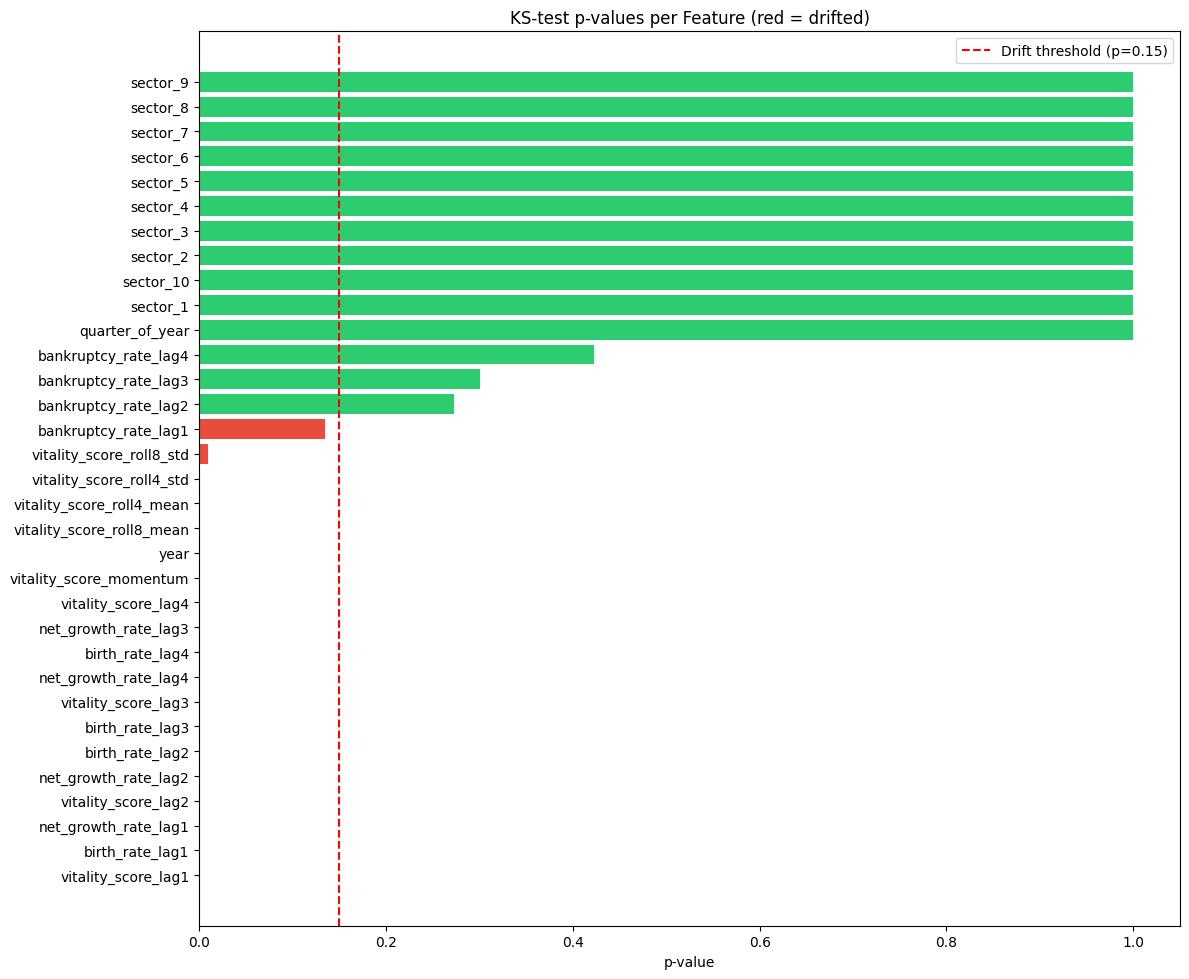

In [3]:
# Visualise: KS p-values per feature
feature_pvals = {
    k: v['p_value'] 
    for k, v in drift_report['per_feature'].items()
}
pval_series = pd.Series(feature_pvals).sort_values()

fig, ax = plt.subplots(figsize=(12, max(4, len(pval_series)*0.3)))
colors = ['#e74c3c' if v < 0.15 else '#2ecc71' for v in pval_series.values]
ax.barh(pval_series.index, pval_series.values, color=colors)
ax.axvline(0.15, color='red', linestyle='--', label='Drift threshold (p=0.15)')
ax.set_title('KS-test p-values per Feature (red = drifted)', fontsize=12)
ax.set_xlabel('p-value')
ax.legend()
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_drift_pvalues.png', dpi=120)
plt.show()


## 4.2 Model Performance Monitoring
Compare the model's MAE on the test set (simulated 'new data')
against the training baseline MAE.


In [4]:
from src.monitoring import monitor_performance

y_test = df_test['target'].values
y_pred_test = predict(artifact, df_test)

perf_report = monitor_performance(
    y_true=y_test,
    y_pred=y_pred_test,
    baseline_mae=artifact['metrics']['mae'],
    threshold_pct=0.20,  # flag if MAE degrades by >20%
)

print("Performance monitoring report:")
for k, v in perf_report.items():
    if k != 'timestamp':
        print(f"  {k}: {v}")


2026-04-16 17:23:49,425 [INFO] ✅ Model performance OK: MAE=0.2385 (baseline=0.2385, +0.0%)


Performance monitoring report:
  baseline_mae: 0.23854
  current_mae: 0.23854
  current_rmse: 0.25367
  degradation_pct: 0.0
  retrain_flag: False


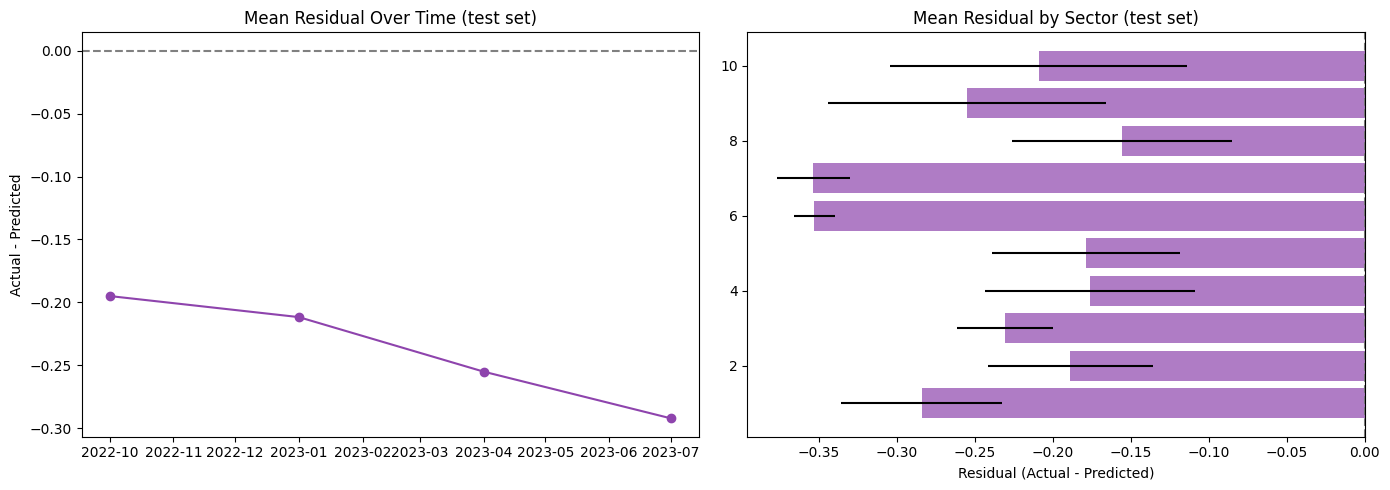


A flat residual time series → no systematic drift over time (good!)
Sectors with large residuals → those sectors are harder to predict.


In [5]:
# Plot residuals over time — look for patterns (if systematic → model needs updating)
df_test_copy = df_test.copy()
df_test_copy['y_pred'] = y_pred_test
df_test_copy['residual'] = df_test_copy['target'] - df_test_copy['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals over time
quarterly_residuals = df_test_copy.groupby('period')['residual'].mean()
axes[0].plot(quarterly_residuals.index, quarterly_residuals.values, 'o-', color='#8e44ad')
axes[0].axhline(0, color='grey', linestyle='--')
axes[0].set_title('Mean Residual Over Time (test set)')
axes[0].set_ylabel('Actual - Predicted')

# Residuals by sector
sector_residuals = df_test_copy.groupby('sector')['residual'].agg(['mean','std'])
axes[1].barh(sector_residuals.index, sector_residuals['mean'], 
             xerr=sector_residuals['std'], color='#8e44ad', alpha=0.7)
axes[1].axvline(0, color='grey', linestyle='--')
axes[1].set_title('Mean Residual by Sector (test set)')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.savefig('../artifacts/reports/fig_residuals.png', dpi=120)
plt.show()

print("\nA flat residual time series → no systematic drift over time (good!)")
print("Sectors with large residuals → those sectors are harder to predict.")


## 4.3 Prediction Distribution Monitoring
Check if the model's prediction distribution has shifted.
Extreme shift (e.g. all predictions near 0) can indicate bad input data
before the actual values are shown


Prediction distribution report:
  ks_statistic: 0.625
  p_value: 0.0
  prediction_drift: True
  new_pred_mean: 0.2832
  new_pred_std: 0.0743
  train_pred_mean: 0.5042
  train_pred_std: 0.211


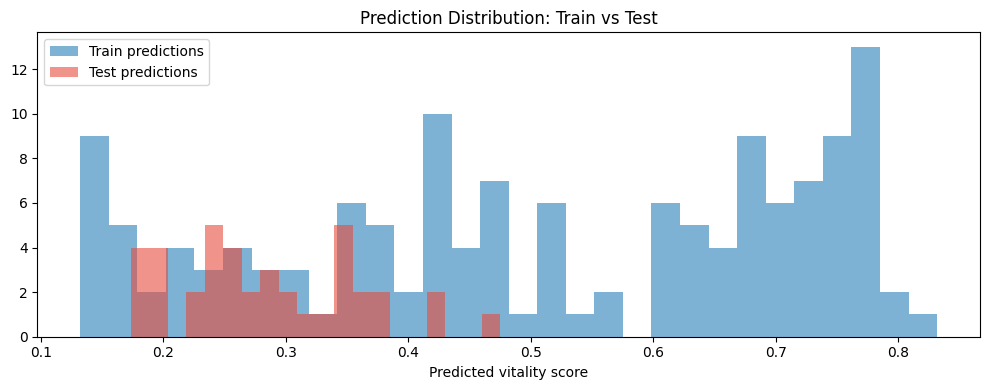

In [6]:
from src.monitoring import monitor_prediction_distribution

y_pred_train = predict(artifact, df_train)
pred_dist_report = monitor_prediction_distribution(y_pred_train, y_pred_test, threshold=0.10)

print("Prediction distribution report:")
for k, v in pred_dist_report.items():
    print(f"  {k}: {v}")

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_pred_train, bins=30, alpha=0.6, color='#2980b9', label='Train predictions')
ax.hist(y_pred_test, bins=20, alpha=0.6, color='#e74c3c', label='Test predictions')
ax.set_title('Prediction Distribution: Train vs Test')
ax.set_xlabel('Predicted vitality score')
ax.legend()
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_prediction_distribution.png', dpi=120)
plt.show()


## 4.4 Save Full Monitoring Report
The monitoring report is a single JSON file that contains all monitoring
results. The FastAPI `/monitoring` endpoint serves this file directly.


In [7]:
from src.monitoring import save_monitoring_report

def make_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serializable(v) for v in obj]
    elif isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

full_report = {
    'data_drift': drift_report,
    'performance': perf_report,
    'prediction_distribution': pred_dist_report,
    'model_metrics': artifact['metrics'],
}

full_report = make_serializable(full_report)
path = save_monitoring_report(full_report, report_dir='../artifacts/reports')
print(f"Monitoring report saved to: {path}")
print(json.dumps({k: '...' for k in full_report.keys()}, indent=2))

2026-04-16 17:23:49,769 [INFO] Monitoring report saved → ../artifacts/reports/monitoring_20260416_172349.json


Monitoring report saved to: ../artifacts/reports/monitoring_20260416_172349.json
{
  "data_drift": "...",
  "performance": "...",
  "prediction_distribution": "...",
  "model_metrics": "..."
}


## 4.5 Retraining Strategy
Based on this monitoring:

| Trigger | Threshold | Action |
|---|---|---|
| Data drift | >30% features drift (KS p<0.15) | Full retrain |
| Performance drop | MAE increase >20% vs baseline | Full retrain |
| Scheduled | Every quarter (DST data release) | Incremental retrain |
| Manual | Via `POST /pipeline/run` API call | Full retrain |

The GitHub Actions workflow (`.github/workflows/pipeline.yml`)
runs `python run_pipeline.py` on a cron schedule aligned to
DST's quarterly release calendar.


In [8]:
# Summary of all figures generated
import os
figures = [f for f in os.listdir('../artifacts/reports') if f.endswith('.png')]
print("Generated visualisations:")
for f in sorted(figures):
    print(f"  artifacts/reports/{f}")


Generated visualisations:
  artifacts/reports/fig_bankruptcies_timeseries.png
  artifacts/reports/fig_drift_pvalues.png
  artifacts/reports/fig_feature_correlation.png
  artifacts/reports/fig_feature_importances.png
  artifacts/reports/fig_new_enterprises_by_sector.png
  artifacts/reports/fig_prediction_distribution.png
  artifacts/reports/fig_predictions_vs_actual.png
  artifacts/reports/fig_residuals.png
  artifacts/reports/fig_train_test_split.png
  artifacts/reports/fig_vitality_scores.png


```
GitHub Actions (quarterly cron)
        ↓
python run_pipeline.py
   ├── 01 Ingest: DST API → raw CSVs
   ├── 02 Preprocess: quarterly panel + vitality score
   ├── 03 Features: lag/rolling features + time split
   ├── 04 Train: XGBoost + MLflow logging
   └── 05 Monitor: drift detection + report
        ↓
FastAPI serves predictions + monitoring report
```
